# [3주차] Transformer 과제

- **과제 목적:** 이번 과제는 하나의 흐름 안에서 Transformer의 핵심 연산을 직접 구현하고, 마스킹 전후를 비교한 뒤, BERT와 GPT의 예측 방식을 관찰하는 과제로 출제해봤습니다. 완성된 코드를 실행하는 것에서 끝내지 않고, 실제로 실행하며 얻은 수치와 출력 결과를 근거로 각 개념을 해석하면서 트랜스포머를 이해해주시면 됩니다!

## 전체 흐름

> Scaled Dot-Product Attention 구현 → Causal Mask 적용 → BERT와 GPT 결과 비교 → 전체 해석

### 제출 시 유의사항
- 코드 셀의 `TODO`와 주석의 빈칸을 모두 채워주세요.
- 서술형 답변은 **본인이 실행해 얻은 값이나 출력**을 반드시 이용해서 작성해주세요.
- 마지막 셀의 생성형 AI 활용 내역을 반드시 작성해주세요.


## 0. 환경 설정

아래 셀을 실행하여 필요한 라이브러리를 설치하고 시드를 고정합니다.

In [1]:
!pip -q install transformers

import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Hugging Face의 다운로드 진행바/경고를 줄여 과제 출력이 너무 길어지지 않게 합니다.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForCausalLM,
)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\juhye\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


# 1. 필수 과제

## 1-1. Scaled Dot-Product Attention 직접 구현

다음 식을 코드로 구현합니다.

$$
\mathrm{Attention}(Q,K,V)
=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

아래 예제에서 각 행은 하나의 토큰을 나타냅니다. 코드의 빈칸과 주석을 채운 뒤, **Attention Score → Weight → Output**의 흐름을 확인해주세요.


In [5]:
# 세 토큰의 Q, K, V 예시
Q = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

# 첫 번째 Query에서 최대 Attention이 하나만 나오도록 세 번째 Key를 [0.5, 0.5]로 둡니다.
K = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 0.5],
])

V = torch.tensor([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0],
])


def scaled_dot_product_attention(Q, K, V, mask=None):
    # [빈칸] d_k는 어떤 벡터의 차원을 뜻하는가?
    # 답: key 벡터의 차원
    d_k = Q.size(-1)

    # TODO 1: Query와 모든 Key의 내적 계산
    scores = Q @ K.transpose(-2,-1)

    # TODO 2: 내적값을 sqrt(d_k)로 나누기
    scaled_scores = scores / math.sqrt(d_k)

    # Mask가 주어진 경우 미래 위치의 score를 -inf로 바꿉니다.
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask, float('-inf'))

    # TODO 3: 마지막 차원에 Softmax를 적용해 Attention Weight 구하기
    weights = torch.softmax(scaled_scores, dim=-1)

    # TODO 4: Attention Weight와 Value의 가중합 계산
    output = weights @ V

    return scores, scaled_scores, weights, output

scores, scaled_scores, weights, output = scaled_dot_product_attention(Q, K, V)

print("[Raw Attention Scores]\n", scores)
print("\n[Scaled Scores]\n", scaled_scores)
print("\n[Attention Weights]\n", weights)
print("\n[Attention Output]\n", output)


[Raw Attention Scores]
 tensor([[1.0000, 0.0000, 0.5000],
        [0.0000, 1.0000, 0.5000],
        [1.0000, 1.0000, 1.0000]])

[Scaled Scores]
 tensor([[0.7071, 0.0000, 0.3536],
        [0.0000, 0.7071, 0.3536],
        [0.7071, 0.7071, 0.7071]])

[Attention Weights]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Attention Output]
 tensor([[6.1546, 3.8454],
        [3.8454, 6.1546],
        [5.0000, 5.0000]])


In [6]:
# 과정 확인 장치: 각 Query의 Attention Weight 합은 1이어야 합니다.
row_sums = weights.sum(dim=-1)
print("각 행의 합:", row_sums)

# TODO 5: row_sums가 모두 1에 가까운지 검증
assert torch.allclose(row_sums, torch.ones_like(row_sums))

# 첫 번째 Query가 가장 크게 참고한 Key의 인덱스
most_attended_key = weights[0].argmax().item()
print("첫 번째 Query가 가장 크게 참고한 Key index:", most_attended_key)


각 행의 합: tensor([1., 1., 1.])
첫 번째 Query가 가장 크게 참고한 Key index: 0


### 1-1 결과 해석

1. 첫 번째 Query가 가장 크게 참고한 Key의 인덱스와 가중치는 얼마인가요?
   - **답: 가장 크게 참고한 인덱스는 0이고, 가중치 값은 0.4555입니다.**
2. 그 Key의 가중치가 가장 큰 이유를 Q와 K의 내적 관점에서 설명해주세요.
   - **답: 첫 번째 Query는 [1,0]이고, 각 Key는 [1,0], [0,1], [0.5, 0.5]입니다. 이를 각각 내적하면 1, 0, 0.5가 됩니다. 따라서 Key 0과의 내적값 1이 가장 크기 때문에 두 벡터의 유사도가 가장 높아 가장 큰 가중치가 부여되었습니다.**
3. Attention Output은 Value 하나를 그대로 선택한 결과인가요, 여러 Value를 결합한 결과인가요?
   - **답: Attention Output은 Value 하나를 그대로 선택한 것이 아니라 모든 Value에 Attention Weight를 곱한 뒤 더한 가중합입니다.**
4. `sqrt(d_k)`로 나누는 Scaling이 필요한 이유를 Softmax와 연결해 설명해주세요.
   - **답: d_k가 커지면 Q, K의 내적값도 커질 수 있고 이를 그대로 softmax에 넣으면 특정 Key에 가중치가 지나치게 집중될 수 있기 때문에 `sqrt(d_k)`로 나누어 softmax가 너무 뾰족해지지 않게 하고 안정적인 Attention Weight와 학습이 가능하도록 합니다.**


## 1-2. Look-ahead Mask 적용하기

같은 Q, K, V에 **Causal Mask(Look-ahead Mask)** 를 적용해 미래 토큰을 보지 못하게 합니다. 마스크 자체와 Masked Self-Attention은 같은 말이 아닙니다.

- **Look-ahead Mask:** 미래 위치를 가리는 마스크
- **Masked Self-Attention:** Self-Attention에 Look-ahead Mask를 적용한 연산

In [8]:
seq_len = Q.size(0)

# TODO 1: 주대각선 위쪽을 True로 갖는 마스크 만들기
# 힌트: torch.triu(..., diagonal=1)
causal_mask = torch.triu(
    torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1
)

_, _, unmasked_weights, _ = scaled_dot_product_attention(Q, K, V)
_, _, masked_weights, masked_output = scaled_dot_product_attention(
    Q, K, V, mask=causal_mask
)

print("[Causal Mask]\n", causal_mask)
print("\n[Mask 적용 전 Weight]\n", unmasked_weights)
print("\n[Mask 적용 후 Weight]\n", masked_weights)
print("\n[Masked Attention Output]\n", masked_output)


[Causal Mask]
 tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

[Mask 적용 전 Weight]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Mask 적용 후 Weight]
 tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.3333, 0.3333, 0.3333]])

[Masked Attention Output]
 tensor([[10.0000,  0.0000],
        [ 3.3024,  6.6976],
        [ 5.0000,  5.0000]])


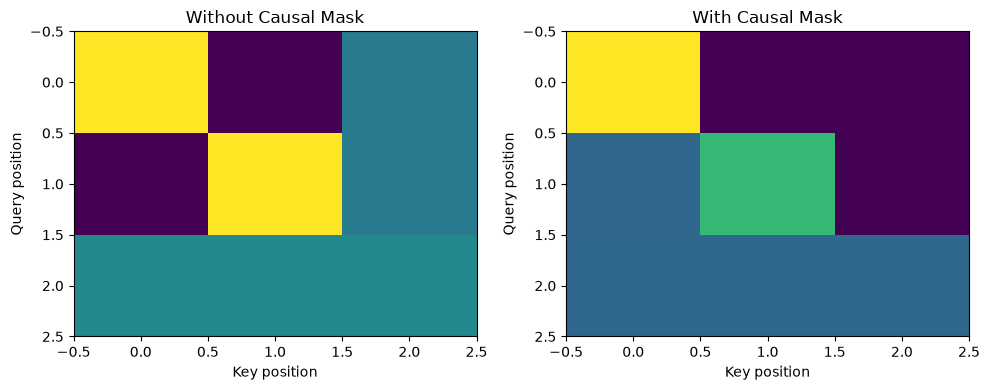

In [9]:
# Attention Weight 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(unmasked_weights.detach().numpy(), aspect="auto")
axes[0].set_title("Without Causal Mask")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

axes[1].imshow(masked_weights.detach().numpy(), aspect="auto")
axes[1].set_title("With Causal Mask")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")

plt.tight_layout()
plt.show()

### 1-2 결과 해석

1. Query index 0은 마스크 적용 후 어느 Key까지 참고할 수 있나요?
   - **답: Key index 0까지만 참고할 수 있습니다.**
2. 마스크 적용 후 Weight 행렬이 삼각형 모양이 되는 이유를 설명해주세요.
   - **답: 각 Query는 현재 위치와 과거의 Key만 참고할 수 있고 미래의 Key는 참고할 수 없기 때문입니다. Query index 0은 Key 0만, Query index 1은 Key 0~1만, Query index 2는 Key 0~2까지 참고할 수 있습니다.**
3. Look-ahead Mask를 적용한 위치의 Weight가 0이 되는 과정을 `-∞ → Softmax`와 연결해 서술해주세요.
   - **답: Look-ahead Mask가 True인 위치의 Attention Score을 -∞로 변경한 뒤 Softmax를 적용합니다. Softmax 공식에 따르면 e^(-∞)=0이므로 Attention Weight가 0이 됩니다.**
4. Padding Mask와 Look-ahead Mask의 목적의 차이를 한 문장씩 간단하게 작성해주세요.
   - **Padding Mask: 실제 정보가 없는 padding token을 Attention 계산에서 제외하기 위해 사용됩니다.**
   - **Look-ahead Mask: 현재 시점에서 아직 알 수 없는 미래 토큰을 참고하지 못 하도록 차단하기 위해 사용됩니다.**


## 1-3. BERT와 GPT의 예측 방식 비교

이제 사전학습 모델을 사용해 두 모델의 차이를 관찰합니다.

- **BERT:** Encoder 기반, 양방향 문맥, Masked Language Model
- **GPT:** Decoder 기반, Causal Mask, 이전 토큰만 이용하는 Autoregressive Language Model

두 모델은 목적이 다르므로 정확도 경쟁이 아니라, **입력과 예측 방식의 차이**를 해석하는 것이 핵심입니다.

In [10]:
# 모델 불러오기
bert_name = "bert-base-uncased"
gpt_name = "gpt2"

# TODO 1: BERT tokenizer와 Masked LM model 불러오기
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForMaskedLM.from_pretrained(bert_name).to(DEVICE)
_ = bert_model.eval()

# TODO 2: GPT tokenizer와 Causal LM model 불러오기
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name).to(DEVICE)
_ = gpt_model.eval()

print("BERT / GPT 모델 로드 완료")


c:\Users\juhye\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\juhye\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\juhye\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_dow

BERT / GPT 모델 로드 완료


In [11]:
# ----- BERT: [MASK]의 앞뒤 문맥을 모두 이용한 단어 예측 -----
# [MASK] 뒤의 "to withdraw money"까지 활용할 수 있다는 점이 핵심
bert_sentence = "I went to the [MASK] to withdraw money."
bert_inputs = bert_tokenizer(bert_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    bert_logits = bert_model(**bert_inputs).logits

mask_positions = (bert_inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=False)
assert len(mask_positions) == 1, "[MASK] 토큰은 정확히 하나만 있어야 합니다."
mask_index = mask_positions[0, 1].item()
mask_logits = bert_logits[0, mask_index, :]

# TODO 3: logit이 높은 상위 5개 토큰의 id 구하기
bert_top_ids = torch.topk(mask_logits, 5).indices
bert_top_tokens = [bert_tokenizer.decode([idx]).strip() for idx in bert_top_ids]
print("문장:", bert_sentence)
print("BERT top-5 predictions:", bert_top_tokens)


문장: I went to the [MASK] to withdraw money.
BERT top-5 predictions: ['bank', 'banks', 'store', 'atm', 'office']


In [12]:
# ----- GPT: 지금까지의 토큰만 이용한 다음 토큰 예측 -----
# GPT는 뒤 문맥을 볼 수 없으므로, 현재까지 주어진 prefix에서 다음 토큰을 예측
gpt_prompt = "I went to the bank to withdraw"
gpt_inputs = gpt_tokenizer(gpt_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    gpt_logits = gpt_model(**gpt_inputs).logits

next_token_logits = gpt_logits[0, -1, :]

# TODO 4: 다음 토큰 후보 상위 5개의 id 구하기
gpt_top_ids = torch.topk(next_token_logits, 5).indices
gpt_top_tokens = [gpt_tokenizer.decode([idx]) for idx in gpt_top_ids]
print("Prompt:", gpt_prompt)
print("GPT next-token top-5:", gpt_top_tokens)


Prompt: I went to the bank to withdraw
GPT next-token top-5: [' money', ' my', ' the', ' $', ' some']


In [13]:
# GPT의 Autoregressive 생성 과정 관찰
prompt = "In natural language processing, Transformer models can"
inputs = gpt_tokenizer(prompt, return_tensors="pt").to(DEVICE)

# TODO 5: max_new_tokens=20, do_sample=False 조건으로 문장 생성
generated_ids = gpt_model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=False,
    pad_token_id=gpt_tokenizer.eos_token_id,
)

print(gpt_tokenizer.decode(generated_ids[0], skip_special_tokens=True))


In natural language processing, Transformer models can be used to create a model that is more accurate than the original model.

Transformer models


### 1-3 결과 해석

> **주의:** BERT/GPT의 상위 토큰과 생성 문장은 라이브러리·모델 버전에 따라 조금 달라질 수 있습니다. 반드시 **본인의 실제 출력값을 사용해** 답변을 작성해주시면 됩니다!

1. BERT의 `[MASK]` 상위 5개 예측 중 문맥상 가장 적절하다고 판단한 토큰은 무엇인가요? 그 이유는 무엇인가요?
   - **답: 가장 적절한 토큰은 `bank`입니다. 실제 BERT의 상위 5개 예측은 ['bank', 'banks', 'store', 'atm', 'office']였고 문장이 'I went to the [MASK] to withdraw money.'이므로 돈을 인출하러 간 장소라는 앞뒤 문맥을 모두 고려했을 때 `bank`가 가장 자연스럽기 때문입니다.**
2. GPT의 다음 토큰 상위 5개 중 자연스럽다고 판단한 후보 2개를 적고, 그 이유도 설명해주세요.
   - **답: GPT의 상위 5개 후보는 [' money', ' my', ' the', ' $', ' some']이고 이 중 `money`, `some`이 가장 자연스럽다고 판단했습니다. 입력 문장이 'I went to the bank to withdraw'까지 주어졌기 때문에 `withdraw money`와 `withdraw some` 모두 자연스럽게 이어질 수 있기 때문입니다.**
3. BERT와 GPT의 차이를 **Bidirectional / Causal / Masked Self-Attention** 용어를 사용해 설명해주세요.
   - **답: BERT는 Bidirectional 방식으로 [MASK]의 좌우 문맥을 모두 참고해서 토큰을 예측합니다. 반면 GPT는 Causal Masked Self-Attention을 사용해 현재 위치보다 더 미래에 있는 토큰을 볼 수 없도록 제한하고 이전의 토큰만을 사용해서 다음 토큰을 예측합니다. 즉 BERT는 양방향 문맥을 활용하는 Masked Language Model, GPT는 이전 토큰을 기반으로 순서대로 다음 토큰을 생성하는 Causal Language Model이라는 점에서 차이가 있습니다.**
4. GPT의 생성 결과를 **Autoregressive** 관점에서 서술해주세요.
   - **답: 실제 생성 결과는 'In natural language precessing, Transformer models can be used to create a model that is more accurate than the original model.'로 이어졌고 GPT는 이 문장 전체를 한 번에 만들어내는 것이 아니라 현재까지 주어진 토큰을 바탕으로 다음 토큰 하나를 예측하고 그 토큰을 다시 입력에 포함시켜서 다음 토큰을 예측하는 과정을 반복합니다. 즉 Autoregressive 방식으로 문장이 순차적으로 만들어집니다.**


# 2. 심화 과제 (선택)

아래 **A/B 중 하나를 선택**하여 수행하세요. 선택한 실험에서는 코드 실행 결과뿐 아니라 **본인이 관찰한 출력값이나 문장 일부를 근거로 해석**해야 합니다.

---

## A안. BERT의 서로 다른 Attention Head 비교

같은 문장을 넣고 BERT의 동일 Layer 안에서 서로 다른 Head가 **특정 Query 토큰(`it`)에서 어떤 Key 토큰을 참고하는지** 비교합니다.

- 비교 문장: `The animal did not cross the street because it was tired.`
- 비교 Layer: 중간층인 Encoder Layer 8 (0-based index 7)
- 비교 Head: Head 0, Head 1
- 비교 Query: `it`
- 확인할 점: 두 Head가 `it`에서 어떤 토큰에 서로 다른 Attention을 주는지

> 마지막 Layer의 전체 Attention heatmap은 `[SEP]` 같은 특수 토큰에 Attention이 몰려 Head 차이가 잘 안 보일 수 있습니다. 따라서 **중간 Layer + 특정 Query 행**을 비교합니다.


tokens: ['[CLS]', 'the', 'animal', 'did', 'not', 'cross', 'the', 'street', 'because', 'it', 'was', 'tired', '.', '[SEP]']
layer attention shape: torch.Size([12, 14, 14])
query token: it (index 9 )


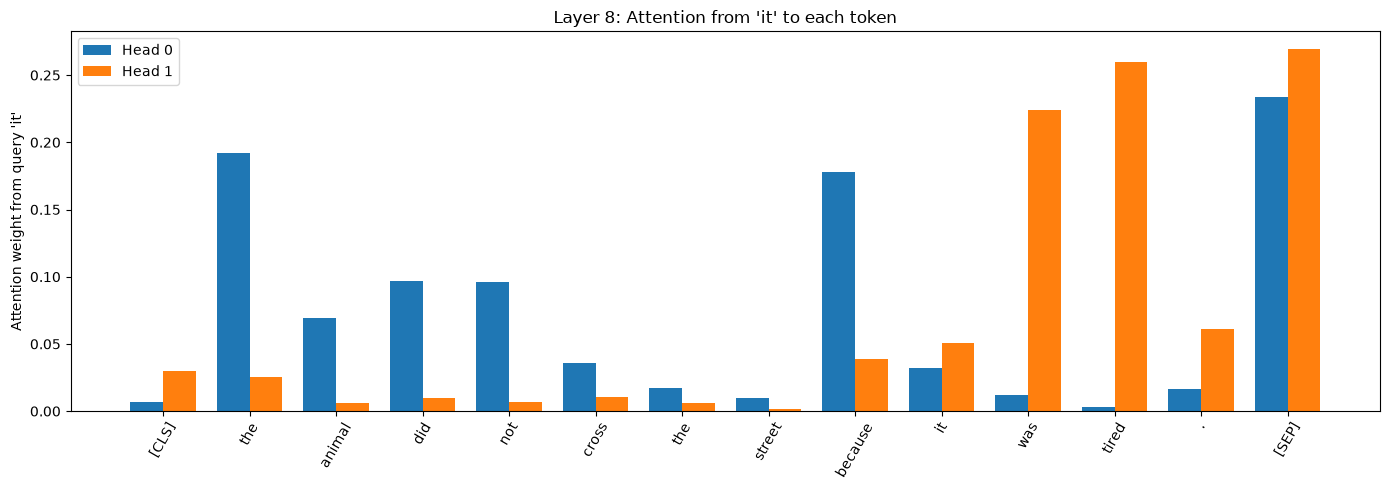

Head 0: 'it'이 가장 크게 참고한 일반 토큰 = 'the' (index=1, weight=0.1923)
Head 1: 'it'이 가장 크게 참고한 일반 토큰 = 'tired' (index=11, weight=0.2598)
Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: 0.084319


In [14]:
# A안: BERT Multi-Head Attention 비교
from transformers import AutoModel

# attention weight를 반환하도록 eager 구현을 사용합니다.
bert_attn_model = AutoModel.from_pretrained(
    bert_name,
    attn_implementation="eager",
).to(DEVICE)
_ = bert_attn_model.eval()

attn_sentence = "The animal did not cross the street because it was tired."
attn_inputs = bert_tokenizer(attn_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    attn_outputs = bert_attn_model(**attn_inputs, output_attentions=True)

# attentions: tuple(num_layers), 각 원소 shape = [batch, num_heads, seq_len, seq_len]
attentions = attn_outputs.attentions
assert attentions is not None, "Attention이 반환되지 않았습니다. attn_implementation='eager' 설정을 확인하세요."

tokens = bert_tokenizer.convert_ids_to_tokens(attn_inputs["input_ids"][0])

# TODO 1: 8번째 Encoder layer(0-based index 7)를 선택
layer_idx = 7
layer_attn = attentions[layer_idx][0].detach().cpu()

# TODO 2: Query 토큰 'it'의 위치 찾기.
it_idx = tokens.index('it')

# TODO 3: Head 0과 Head 1에서 Query='it'이 모든 Key 토큰에 주는 Attention 가져오기
head0_it = layer_attn[0, it_idx, :]
head1_it = layer_attn[1, it_idx, :]

print("tokens:", tokens)
print("layer attention shape:", layer_attn.shape)
print("query token:", tokens[it_idx], "(index", it_idx, ")")

# 특수 토큰까지 포함한 전체 분포를 막대그래프로 비교
x = np.arange(len(tokens))
width = 0.38
plt.figure(figsize=(14, 5))
plt.bar(x - width/2, head0_it.numpy(), width, label="Head 0")
plt.bar(x + width/2, head1_it.numpy(), width, label="Head 1")
plt.xticks(x, tokens, rotation=60)
plt.ylabel("Attention weight from query 'it'")
plt.title(f"Layer {layer_idx+1}: Attention from 'it' to each token")
plt.legend()
plt.tight_layout()
plt.show()

# 각 Head에서 'it'이 가장 많이 참고한 일반 토큰 확인
# [CLS], [SEP]는 해석을 위해 제외합니다.
special_ids = {0, len(tokens)-1}
valid_indices = [i for i in range(len(tokens)) if i not in special_ids]

def top_key_for_head(weights, valid_indices):
    best = max(valid_indices, key=lambda i: float(weights[i]))
    return best, tokens[best], float(weights[best])

for h, w in [(0, head0_it), (1, head1_it)]:
    idx, tok, val = top_key_for_head(w, valid_indices)
    print(f"Head {h}: 'it'이 가장 크게 참고한 일반 토큰 = {tok!r} (index={idx}, weight={val:.4f})")

mean_abs_diff = torch.mean(torch.abs(head0_it - head1_it)).item()
print(f"Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: {mean_abs_diff:.6f}")


### A안 결과 해석

- **선택: A** A
- **변경한 조건: BERT의 8번째 Encoder Layer에서 동일한 Query 토큰 `it`에 대해 Head 0과 Head 1의 Attention 분포를 비교함**
- **관찰 결과: Query 토큰 `it`을 기준으로 확인한 결과 Head 0은 일반 토큰 중 `the`에 가장 큰 Attention weight인 0.1923을 부여하였습니다. 반면 Head 1은 `tired`에 가장 큰 Attention Weight인 0.2598을 부여하였습니다. 또한 두 Head의 Attention 분포 평균 절대 차이는 0.084319로 나타나 동일한 `it`이라는 Query를 입력하더라도 Head에 따라 서로 다른 토큰에 주목한다는 것을 알 수 있었습니다.**
- **해석: 이러한 차이는 Multi-Head Attention에서 각 Head가 서로 독립적인 Q/K/V projection을 학습하기 때문이라고 해석할 수 있습니다. 같은 `it` 토큰이더라도 Head마다 서로 다른 가중치 행렬을 통해 Query와 Key가 생성되므로 QK^T로 계산되는 Attention Score가 달라집니다. 그 결과 Head 0은 `the`에 상대적으로 높은 Attention을 주는 반면 Head 1은 `tired`에 높은 Attention을 주는 등 각 Head가 문장에서 서로 다른 관계와 정보를 포착할 수 있습니다.** 두 Head의 Attention 분포가 왜 다를 수 있는지 Multi-Head Attention의 Q/K/V projection과 연결하여 설명하세요.

---

## B안. GPT Temperature에 따른 생성 다양성 비교

같은 Prompt에서 **temperature만 변경**했을 때 생성 결과의 다양성과 자연스러움이 어떻게 달라지는지 비교합니다.

- Prompt는 모든 실험에서 동일하게 유지합니다.
- `temperature = 0.3, 0.8, 1.5`를 비교합니다.
- 각 temperature에서 **3회 생성**합니다.
- `top_k=50`, 생성 길이 등 나머지 조건은 동일하게 유지합니다.
- 생성 결과의 **다양성(Diversity)** 과 **문맥의 자연스러움(Coherence)** 을 비교합니다.

### 확인할 질문
1. 어느 temperature에서 3개의 생성 결과가 가장 비슷했고, 어느 temperature에서 가장 다양했나요? 실제 생성 문장의 일부를 근거로 설명해세요.
2. temperature가 높아질수록 문장의 자연스러움과 다양성이 어떻게 변했나요? 예상과 다른 결과가 나왔다면 그 결과도 그대로 편하게 적어주세요.
3. temperature가 Softmax 확률분포에 미치는 영향을 위 실험 결과와 연결해 설명하세요.


In [ ]:
# B안: temperature에 따른 GPT 생성 다양성 비교
# 여러 방향으로 자연스럽게 이어질 수 있는 prompt를 사용합니다.
prompt = "Once upon a time, a robot discovered"

# TODO 1: 비교할 temperature 값을 입력
temps = [____, ____, ____]

# top_k, 생성 길이 등은 모든 조건에서 동일하게 고정하고
# temperature만 변경하여 그 효과를 비교합니다.
for temp in temps:
    print(f"\n===== temperature={temp} =====")

    # 같은 temperature에서도 3번 생성하여 결과의 다양성을 확인합니다.
    for trial in range(3):
        # 각 temperature에서 같은 trial끼리는 동일한 seed를 사용합니다.
        torch.manual_seed(SEED + trial)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + trial)

        temp_inputs = gpt_tokenizer(
            prompt,
            return_tensors="pt"
        ).to(DEVICE)

        generated = gpt_model.generate(
            **temp_inputs,
            # TODO 2: 새롭게 생성할 토큰 수를 40으로 설정
            max_new_tokens=____,
            # TODO 3: sampling을 사용하도록 설정
            do_sample=____,
            # TODO 4: 현재 반복문의 temperature를 적용
            temperature=____,
            # 모든 조건에서 동일하게 유지합니다.
            top_k=50,
            pad_token_id=gpt_tokenizer.eos_token_id,
        )

        text = gpt_tokenizer.decode(
            generated[0],
            skip_special_tokens=True
        )

        print(f"\n[생성 {trial + 1}]")
        print(text)


### B안 결과 해석

- **선택:** B
- **변경한 조건:** 어떤 조건을 고정하고 무엇만 변경했는지 작성하세요.
- **관찰 결과:** temperature별 3개의 실제 생성 결과를 비교하고, 구체적인 문장 일부를 인용하세요.
- **해석:** `temperature → Softmax 확률분포 → 다양성/자연스러움`의 관계를 설명하세요.
- **주의:** Sampling 결과는 확률적이므로 이론적인 경향과 완벽하게 일치하지 않을 수 있습니다. 예상과 다른 결과가 나오더라도 실제 출력값을 근거로 타당하게 해석하세요.


# 3. 전체 결과 정리 및 회고

아래 표를 **본인의 실제 실행 결과**를 바탕으로 채워주세요.

| 단계 | 본인이 관찰한 핵심 결과 | 연결되는 개념 |
|---|---|---|
| Attention 직접 구현 | 첫 번째 Query는 Key 0에 가장 높은 가중치 0.4555를 부여했고, Attention Output은 [6,1546, 3.8454]로 여러 Value가 가중합되어 생성됨 | Scaled Dot Product Attention |
| Causal Mask 적용 | Mask 적용 후 각 Query가 자신보다 미래에 위치한 토큰에 Attention을 주지 못 하는 것을 확인함 | Causal Mask, Masked Selft Attention, Autoregressive |
| BERT 실험 | "I went to the [MASK] to withdraw money."에서 [MASK] 위치를 예측할 때 앞뒤 문맥을 모두 활용해서 후보를 결정함 | Bidirectional Self Attention |
| GPT 실험 | "In natural language processing, Transformer models can" 이후 "be used to create a model that is more accurate than the original..."처럼 앞에서 생성된 토큰을 기반으로 다음 토큰을 순차적으로 생성함 | Causal Self Attention |

1. **가장 어려웠던 단계와 해결 방법**
   - 답: Scaled Dot-Product Attention을 직접 구현하는 과정이 가장 어려웠습니다. 코드 구현해본적이 없어 ai의 도움을 받아 코드 작성을 해결했습니다.
2. **실행 전 예상과 실제 결과가 가장 달랐던 부분**
   - 답: Attention에서는 가장 관련성이 높은 하나의 Value가 거의 선택될 것이라고 예상했지만 실제로는 첫 번째 Query의 최대 Attention Weight가 0.4555였고 나머지 Key에서도 0.2246, 0.3199의 가중치가 분배되었습니다. 따라서 Attention Output도 하나의 Value를 그대로 선택하는 것이 아니라 여러 Value를 가중합한 값이 되었습니다. 이를 통해 Attention은 관련성에 따라 여러 정보의 비중을 조절하여 결합하는 방식이라는 점을 확인할 수 있었습니다.
3. **기술블로그의 ‘과제 복습’ 섹션에 정리할 핵심 개념**
   - 답: Scaled Dot-Product Attention과 Causal Mask를 중심으로 정리하고 싶습니다. 특히 Causal Mask가 미래 토큰의 Attention Score을 차단해서 GPT의 Autoregressive 생성을 가능하게 하는 원리와 이를 BERT의 Bidirectional Attention과 비교해서 정리하고 싶습니다.


# 4. 생성형 AI 활용 방법 및 대화 내역

> **반드시 작성하세요.** 문제를 풀면서 GPT, Claude 등 생성형 AI를 어디에 어떻게 사용했는지 기록합니다.

## 1) 활용한 생성형 AI
- 사용한 도구: Chat GPT
- 사용한 문제/단계: 코드 초안(1-1), 답안 수정(1-1-4), 답안 수정(1-3-3)
- 사용 목적: `개념 확인 / 오류 해결 / 코드 초안 / 결과 해석 / 기타`

## 2) AI 답변을 그대로 사용하지 않고 직접 검증한 방법
- 답: 다른 ai로 교차검증하였습니다.

## 3) AI와의 실제 대화 내역
### 대화 내역
#### 1. 1-1 코드 초안
TODO 1에는 이게 들어가면 돼:

```python
scores = Q @ K.transpose(-2, -1)
```
즉 전체는:
```python
# TODO 1: Query와 모든 Key의 내적 계산
scores = Q @ K.transpose(-2, -1)
```
왜 이렇게 쓰냐면
Attention Score는
[QK^T]
로 계산하기 때문이야.
* `Q`: Query 벡터들
* `K`: Key 벡터들
* `K.transpose(-2, -1)`: (K^T)
* `@`: 행렬곱
따라서 **각 Query와 모든 Key 사이의 내적값**이 `scores`에 들어가.
지금 예제처럼 Q, K가 단순한 2차원 행렬이라면
```python
scores = Q @ K.T
```
도 똑같이 작동해. 다만 `transpose(-2, -1)`이 배치 차원이 추가되어도 사용할 수 있어서 더 일반적인 Attention 구현 방식이야.

#### 2. 1-1-4 결과 해석
응, 맞아. 핵심 이유가 바로 Softmax가 너무 뾰족해지는 것을 막기 위해서야.
조금 더 정확히 말하면:
[\text{Attention}(Q,K,V)
=======================
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V]
여기서 (d_k)가 커지면 Query와 Key의 내적 (QK^T)의 크기도 커지는 경향이 있어.
예를 들어 Softmax에
[[1,2,3]]
이 들어가는 것보다
[[10,20,30]]
처럼 큰 값들이 들어가면 가장 큰 값 하나에 확률이 거의 몰려버려. 즉 **Softmax 분포가 지나치게 뾰족해져.**
그러면 나머지 값들의 확률은 거의 0이 되고, Softmax의 gradient도 매우 작아질 수 있어서 **학습이 불안정하거나 느려질 수 있어.**
그래서
[QK^T \div \sqrt{d_k}]
를 해서 score의 크기를 적절하게 줄여주는 거야.
**과제 답안으로는 이렇게 쓰면 충분해:**
> (d_k)가 커질수록 Query와 Key의 내적값이 커질 수 있으며, 큰 값이 Softmax에 입력되면 특정 Key에 확률이 과도하게 집중되어 분포가 뾰족해지고 gradient가 작아질 수 있다. 따라서 (\sqrt{d_k})로 나누어 Attention Score의 크기를 조절하고 Softmax가 지나치게 뾰족해지는 것을 방지한다.
즉 **`√d_k로 나눈다 → score 크기 조절 → Softmax 과도한 포화 방지 → 안정적인 학습`** 이 흐름으로 기억하면 돼.

#### 3. 1-3-3 결과 해석
응, **전체적인 내용은 맞아.** 다만 한 군데만 표현을 조금 고치는 게 더 정확해.
`Causal Masked Self-Attention`보다는 **`Causal Mask를 적용한 Masked Self-Attention`** 또는 그냥 **`Masked Self-Attention`**이라고 쓰는 게 강의에서 배운 용어와 더 잘 맞아. 앞에서 배운 것처럼 **Causal Mask는 미래 위치를 가리는 마스크 자체**, **Masked Self-Attention은 그 마스크를 Self-Attention에 적용한 연산**이기 때문이야.
수정 추천 답안
> **BERT는 Bidirectional Self-Attention을 사용하여 [MASK] 위치의 왼쪽과 오른쪽 문맥을 모두 참고해 토큰을 예측합니다. 반면 GPT는 Causal Mask를 적용한 Masked Self-Attention을 사용하여 현재 위치보다 미래에 있는 토큰을 볼 수 없도록 제한하고, 이전 토큰들만을 이용해 다음 토큰을 예측합니다. 즉, BERT는 양방향 문맥을 활용하는 Masked Language Model이고, GPT는 이전 토큰을 기반으로 순차적으로 다음 토큰을 생성하는 Causal Language Model이라는 차이가 있습니다.**
이렇게 쓰면 문제에서 요구한 **Bidirectional / Causal / Masked Self-Attention** 세 용어도 모두 정확하게 들어가고, 앞의 1-2 실험과 1-3 실험 내용도 잘 연결돼.



